<a href="https://colab.research.google.com/github/CleavDcos/News-Sentiment-Analysis-using-LoRA-PEFT-method-with-SFTTrainer/blob/main/Fine_Tune_LLM_with_PEFT_LORA_using_SFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


We'll perform financial news sentiment classification using the `Daniel-ML/sentiment-analysis-for-financial-news-v2` dataset, which contains financial news labeled as 'positive', 'negative', or 'neutral'.

**What We'll Build & Compare:**

A system to classify Financial News, comparing two different approaches:
1.  **Zero-Shot Open Source:** Using a pre-trained, small open-source model (like Gemma-1B) without any fine-tuning.
2.  **Fine-Tuned Open Source:** Fine-tuning the same open-source model on this dataset within Colab using efficient techniques (PEFT/LoRA).

**Tech Stack (The Tools We'll Use):**

*   **Python & Google Colab (with GPU):** Our environment.
*   **Hugging Face `transformers`, `datasets`, `accelerate`, `bitsandbytes`:** For OS models and data.
*   **Hugging Face `peft`:** PEFT (Parameter-Efficient Fine-Tuning) is a library for efficiently adapting large pretrained models to various downstream applications without fine-tuning all of a model’s parameters because it is prohibitively costly. https://huggingface.co/docs/peft/en/index
*   **Hugging Face `trl`:** TRL (Transformer Reinforcement Learning) is a full stack library where we provide a set of tools to train transformer language models with methods like Supervised Fine-Tuning (SFT). https://huggingface.co/docs/trl/en/index
*   **`scikit-learn`:** For calculating evaluation metrics.
*   **`torch`:** The underlying deep learning framework.

In [ ]:
print("Installing necessary libraries for fine-tuning and evaluation...")

!pip install -q transformers accelerate torch datasets peft trl openai scikit-learn gradio
# !pip install -q transformers accelerate bitsandbytes torch datasets peft trl openai scikit-learn gradio


Installing necessary libraries for fine-tuning and evaluation...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.6 MB/s eta 0:00:00


In [ ]:
import os
from huggingface_hub import login, notebook_login
print("Attempting Hugging Face login...")

notebook_login()
print("HF Login successful (or token already present)!")

Attempting Hugging Face login...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HF Login successful (or token already present)!


In [ ]:
import torch
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig,  # For quantization config
)
from datasets import load_dataset, Dataset, DatasetDict
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training  # PEFT tools
from trl import SFTTrainer  # The fine-tuning trainer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import json  # For OpenAI JSONL format
import time  # For waiting on OpenAI jobs
from IPython.display import display, Markdown
import random

print("Core libraries imported.")

# Check for GPU availability (Crucial for fine-tuning)
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Fine-tuning requires a GPU. Please enable GPU in Runtime settings.")
    # Optionally exit or raise an error here


Core libraries imported.
GPU detected: Tesla T4


In [ ]:
# Link to the dataset on Hugging Face: https://huggingface.co/datasets/Daniel-ML/sentiment-analysis-for-financial-news-v2/viewer
dataset_id = "Daniel-ML/sentiment-analysis-for-financial-news-v2"

print(f"Loading dataset: {dataset_id}...")
labeled_dataset = load_dataset(dataset_id, split = "train")  # Load the main split
print("Dataset loaded successfully!")

# Let's view the dataset
print("\n--- Dataset Information ---")
print(labeled_dataset)


Loading dataset: Daniel-ML/sentiment-analysis-for-financial-news-v2...


README.md:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

pd_df_json.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4846 [00:00<?, ? examples/s]

Dataset loaded successfully!

--- Dataset Information ---
Dataset({
    features: ['sentiment', 'text'],
    num_rows: 4846
})


In [ ]:
# Let's explore how many unique lables exist in the dataset

labels = labeled_dataset.to_pandas()['sentiment'].unique().tolist()
print(f"Unique labels in the dataset: {labels}")


Unique labels in the dataset: ['neutral', 'negative', 'positive']


In [ ]:
#Lets split the data into Train(90%) and Test(10%) Splits
print("\n split into train test split")
train_test_split_ratio=0.10
seed=42 # for reproducibility, ie everytime u run it, you'll get the same split,  hence consistent results

split_dataset = labeled_dataset.train_test_split(
    test_size = train_test_split_ratio,
    seed = seed,
    shuffle = True,  #to put dataset in random order so LLM doesnt learn in default order , 1,2,3 from dataset

)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print("\nTrain Test split complete")


 split into train test split
Train dataset size: 4361
Test dataset size: 485

Train Test split complete


✅ Train set (learning phase)
Model sees this data
Adjusts weights
Learns patterns

✅ Test set (evaluation phase)
Model has NEVER seen this
Used to check:
real performance
generalization

🔥 Simple analogy
Train set → practice questions
Test set → final exam

👉 If you only practice and never test → you don’t know if you’re actually good

🚨 What happens if you DON’T split?
Model memorizes training data
Looks very accurate ❌
Fails on new inputs ❌

👉 This is called overfitting



Without seed:

Every run → different split

Run 1 → different train/test
Run 2 → different train/test

👉 Results become inconsistent ❌

With seed:
Run 1 → same split

Run 2 → same split

👉 Reproducible results ✅


In [ ]:
# define a function that performs chat messages formatting
# We will use "apply_chat_template()" which wraps the messages in a format the model understands
# Just like giving it a movie script so it knows who’s speaking and when to reply.
# It takes a list of messages (like a chat between a user and an assistant) and turns it into one long, properly formatted text, exactly how the model expects to read it.

def format_for_sft_gemma(example, tokenizer):

    # Define the conversation structure
    system_prompt = "Classify the sentiment of the following sentence from News as positive, negative, or neutral."
    user_prompt = f"Sentence: {example['text']}"
    assistant_response = example['sentiment'] # The target label

    messages = [
        {"role": "user", "content": f"{system_prompt}\n{user_prompt}"}, # Combine system/user for simplicity here
        {"role": "assistant", "content": assistant_response}
    ]
    # Apply the tokenizer's chat template.
    # tokenize = False: means we want the text output, not token IDs.
    # add_generation_prompt = False: means we’re NOT adding the assistant prompt to generate the response. We already provided the assistant's message
    formatted_text = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = False)
    return {"text": formatted_text}

print("\nSupervised Fine Tuning (SFT) Trainer formatting function defined")



Supervised Fine Tuning (SFT) Trainer formatting function defined


In [ ]:

from tqdm.notebook import tqdm  # Progress bar meaning takadom "progress" in Arabic

# Let's choose the Gemma 3.1B Instruct model by Google
# It's a small instruction-tuned LLM that's good for chat, Q&A, etc.
os_model_id = "google/gemma-3-1b-it"

# Let's define the quantization configuration
quantization_config = BitsAndBytesConfig(
    load_in_4bit = True, # Use 4-bit weights (saves lots of RAM)
    bnb_4bit_quant_type = "nf4", # nf4 is a better 4-bit format (Non-Float 4)
    bnb_4bit_compute_dtype = torch.float16 # Math is done in float16 for speed
)

# Let's load the Tokenizer associated with the model. Tokenizers convert text to tokens (numbers).
# It’s like the model’s language interpreter.
base_os_tokenizer = AutoTokenizer.from_pretrained(os_model_id)

# Set pad token if missing (Gemma often doesn't have one)
# A pad token is a special token used to make all input sequences the same length in a batch.such that in a batch of tokens, if there is a space wasted , it will be filled with pad token
if base_os_tokenizer.pad_token is None:
    base_os_tokenizer.pad_token = base_os_tokenizer.eos_token
    print(f"Set pad_token to eos_token ({base_os_tokenizer.eos_token})")


In [ ]:
# Sample input dictionary
#SO below u can see the format with how the Gemma Model was trained, ie using bos and all
#Hence formating th text is necessary for the model to understand to perform fine tuning, by formatting our training data.
# <bos>                      → Beginning of sequence (tells the model: "Start reading")
# <start_of_turn>user        → Start of the user's turn
# Classify the sentiment...  → Instruction and user input
# <end_of_turn>              → End of user input
# <start_of_turn>model       → Start of the assistant/model's reply
# positive                   → The expected response
# <end_of_turn>              → End of assistant reply

example = {
    "text": "The economy is showing signs of recovery after a tough year.",
    "sentiment": "positive"
}

# Apply your formatting function
formatted_example = format_for_sft_gemma(example, base_os_tokenizer)

# Print the result
print("\n--- Sample Formatted Prompt ---")
print(formatted_example["text"])

Before Fine Tuning, we will check how the model performs with inference only, ie no fine tuning, just directluy querying the model

This is called Zero Shot Classfication

We can use this to compare the results with the Fine Tuned Model

In [1]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    BitsAndBytesConfig,  # For quantization config
)
import torch
import transformers

In [ ]:
from tqdm.notebook import tqdm  # Progress bar

# Load Base Model (Quantized)
quantization_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4", # Recommended type
    bnb_4bit_compute_dtype = torch.float16
)

base_os_tokenizer = AutoTokenizer.from_pretrained(os_model_id)
if base_os_tokenizer.pad_token is None:
    base_os_tokenizer.pad_token = base_os_tokenizer.eos_token

#Load Model
base_os_model = AutoModelForCausalLM.from_pretrained(
    os_model_id,
    quantization_config = quantization_config,
    device_map = "auto",
    torch_dtype = torch.float16
)
# Ensure model pad token ID is updated if tokenizer's was
base_os_model.config.pad_token_id = base_os_tokenizer.pad_token_id
print("Base Gemma model and tokenizer loaded successfully.")

In [ ]:
#Now apply SFT formatting to the trainig and testing dataset to format the dataset to send it to LLM
print("\nFormatting data for SFTTrainer (Gemma format)...")

sft_train_dataset = train_dataset.map(
    format_for_sft_gemma,
    fn_kwargs = {"tokenizer": base_os_tokenizer},
    remove_columns = train_dataset.column_names,
)
sft_test_dataset = test_dataset.map(
              format_for_sft_gemma,
              fn_kwargs={"tokenizer": base_os_tokenizer},
              remove_columns=list(test_dataset.features)
)

print("SFTTrainer (Gemma) formatting complete.")
print("Sample SFT Gemma format:")
print(sft_train_dataset[0]['text'])

In [ ]:
# define Zero-Shot Classification Prompt Function (Gemma)
def create_zeroshot_prompt_gemma(sentence, tokenizer):

    """Creates zero-shot prompt using Gemma chat template."""
    system_prompt = f"Classify the sentiment of the following sentence from Financial News. Respond with ONLY ONE of the following labels: {', '.join(labels)}."
    user_prompt = f"Sentence: {sentence}"
    messages = [
        {"role": "user", "content": f"{system_prompt}\n{user_prompt}"},
    ]
    # Apply template, add_generation_prompt=True adds the assistant turn marker
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt


In [ ]:
# Inference Function for Zero-Shot (Gemma)
# This function runs inference using the prompt generated above and returns the predicted sentiment label.
# It Gets the formatted prompt using the first function "create_zeroshot_prompt_gemma".
# It then tokenizes the prompt and sends it to the appropriate device (e.g., GPU):
def classify_zero_shot_os_gemma(sentence, model, tokenizer):

    prompt = create_zeroshot_prompt_gemma(sentence, tokenizer)
    inputs = tokenizer(prompt, return_tensors = "pt", truncation = True, max_length = 512).to(model.device)

    eos_id = tokenizer.eos_token_id          # eos_token_id: end of sentence
    pad_id = tokenizer.pad_token_id          # pad_token_id: padding token

    # Run the model to generate output, we are not performing gradient tracking since it's only inference!
    with torch.no_grad():

      outputs = model.generate(
          **inputs,
          max_new_tokens = 10, # Limits the number of tokens the model can generate
          eos_token_id = eos_id,
          pad_token_id = eos_id,
          do_sample = False
      )
    # Extracts and decode the generated text
    response_ids = outputs[0][inputs['input_ids'].shape[1]:]
    response_text = tokenizer.decode(response_ids, skip_special_tokens=True).strip()

    # print(f"Generated Text (Gemma): {response_text}")

    # Clean and Validate Output
    labels = ["neutral", "negative", "positive"]

    predicted_label = "Unknown"
    for label_text in labels:
        if label_text.lower() in response_text.lower(): # Simple check if label is present
              predicted_label = label_text
              break

    print(f"Predicted Label: {predicted_label}")
    return predicted_label


In [ ]:
true_labels = []

#extract the ground truth (target output) which represents the True class
true_labels = [ex['sentiment'] for ex in test_dataset]
true_labels

In [ ]:
# --- Evaluate on Test Set ---
base_os_predictions = [] # Renaming for clarity if needed, but reusing is fine

# perform inference on all testing datasets using the pre-trained Gemma LLM
for example in tqdm(test_dataset):
    predicted_label = classify_zero_shot_os_gemma(example['text'], base_os_model, base_os_tokenizer)
    base_os_predictions.append(predicted_label)


In [ ]:
print("\n--- Base Gemma Model: Zero-Shot Evaluation Results ---")
valid_indices = [i for i, p in enumerate(base_os_predictions) if p not in ["Error", "Unknown"]]
filtered_preds = [base_os_predictions[i] for i in valid_indices]
filtered_true = [true_labels[i] for i in valid_indices]

accuracy = accuracy_score(filtered_true, filtered_preds)
report = classification_report(filtered_true, filtered_preds, labels=labels, zero_division=0, target_names=labels)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
# (Optional: show sample predictions)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(filtered_true, filtered_preds, labels=labels)

# Create heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Base Gemma Model (Zero-Shot)")
plt.tight_layout()
plt.show()

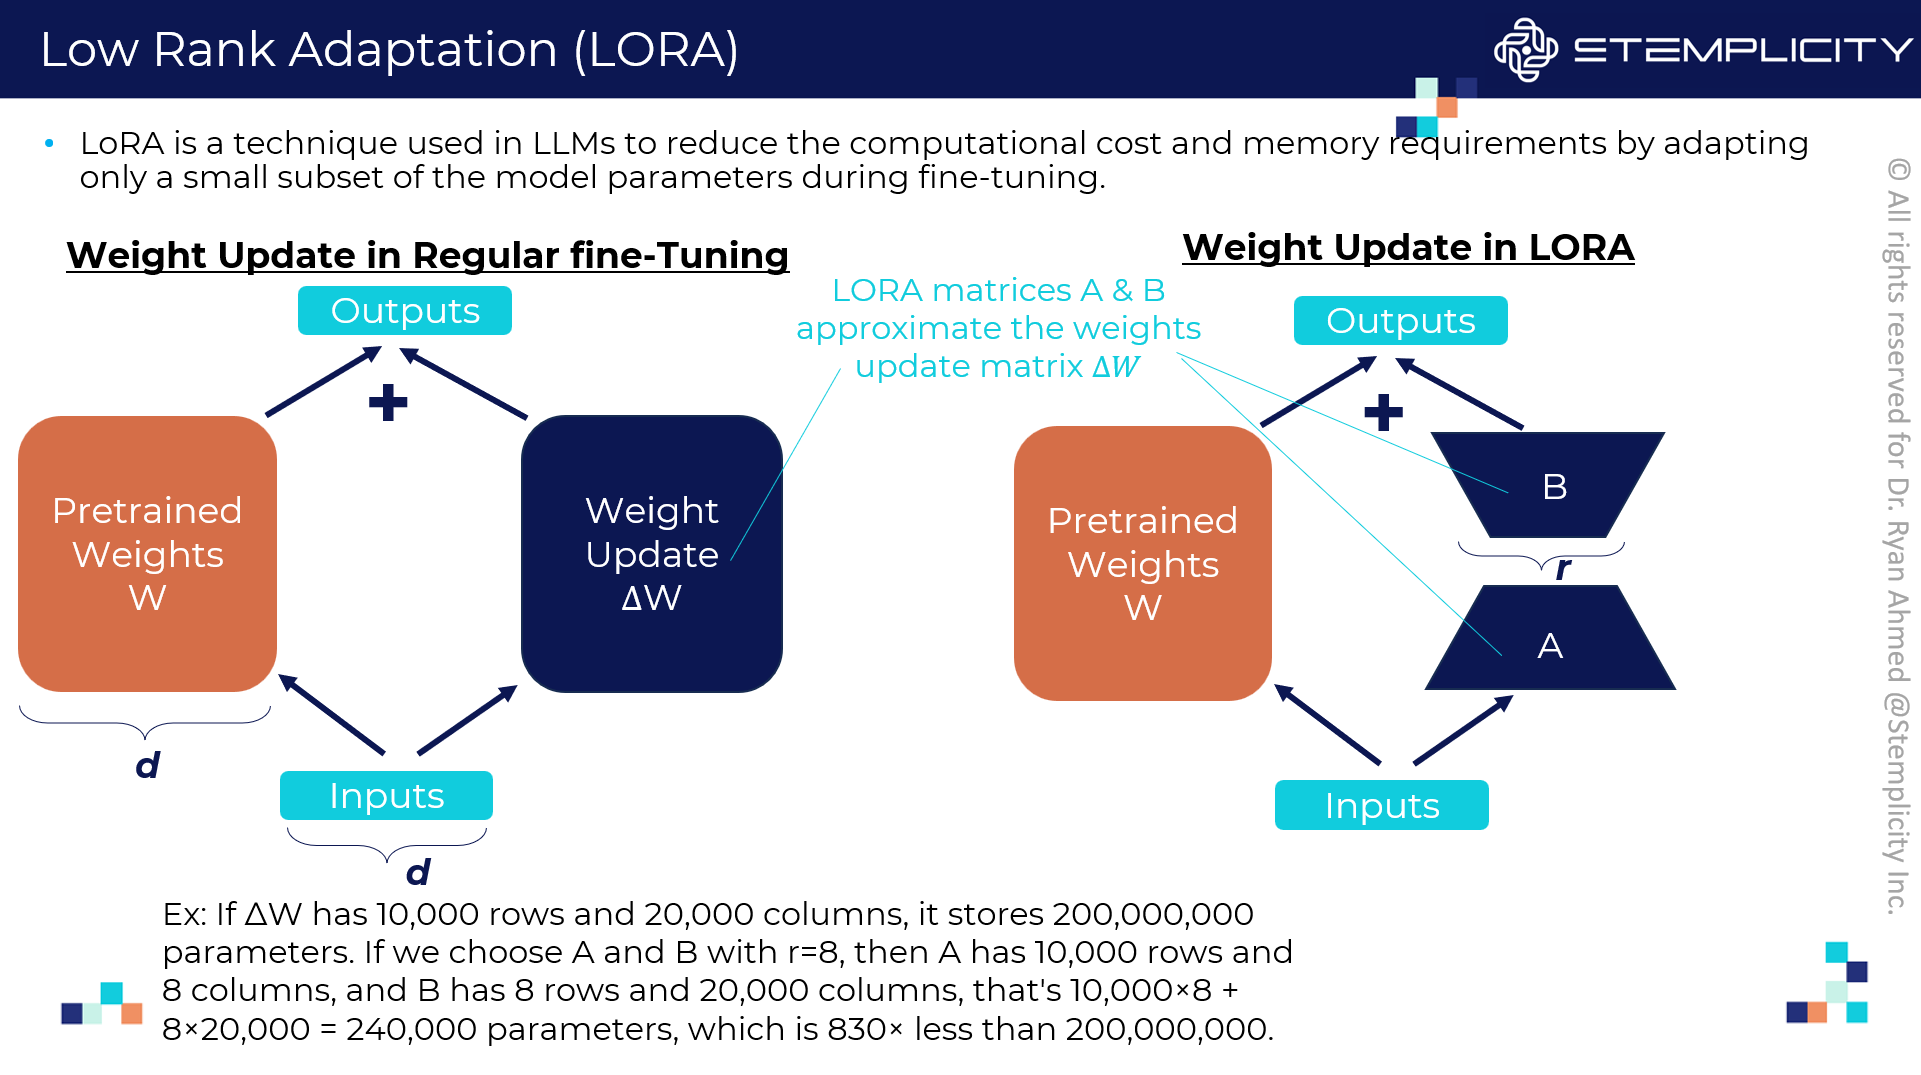

In [ ]:
- LORA Paper: https://arxiv.org/abs/2106.09685

Hence now to Fine Tune we will use PEFT(LoRA) method, for efficient fine tuning without needing much VRAM.


- LORA Paper: https://arxiv.org/abs/2106.09685




**Key Concepts:**
*   **PEFT (Parameter-Efficient Fine-Tuning):** Instead of updating all the billions of parameters in the LLM, PEFT methods like LoRA add small, trainable "adapter" layers. We only train these adapters, which is much faster and uses far less memory.
*   **LoRA (Low-Rank Adaptation):** A popular PEFT technique that injects trainable low-rank matrices into the model's layers.
*   **`SFTTrainer`:** A convenient Hugging Face trainer class designed for Supervised Fine-tuning tasks where the input is formatted text (like our prompts) and the model learns to generate the desired output (the label).

**Steps:**
1.  **Load Base Model (again, if needed):** Ensure the base model and tokenizer are loaded, this time prepared for training (using `prepare_model_for_kbit_training`).
2.  **Configure LoRA:** Define `LoraConfig` specifying which parts of the model to adapt and the LoRA parameters (like rank `r`, `alpha`).
3.  **Configure Training Arguments:** Set hyperparameters like learning rate, batch size, number of epochs, output directory using `TrainingArguments`.
4.  **Initialize `SFTTrainer`:** Pass the model, tokenizer, datasets, LoRA config, and training arguments.
5.  **Start Training:** Call `trainer.train()`.
6.  **Save Adapter:** Save the trained LoRA adapter weights using `trainer.save_model()`.
7.  **Load Fine-tuned Model:** Load the base model *plus* the trained LoRA adapter weights for evaluation.



In [ ]:
# A Quick reminder to our formatted training dataset in an SFT-Trainer format.
# The `SFTTrainer` works by training the model on a Causal Language Modeling objective.
# This means the model learns to predict the next token in a sequence.
# By providing the entire formatted text (including the `assistant`'s response, i.e., the correct label),
# the model learns that after seeing the system prompt and the user sentence,
# the most likely next token sequence is the correct label (e.g., "negative" followed by `<|im_end|>`).
# It learns the mapping from input (prompt + sentence) to output (label) implicitly through next-token prediction on this structured text.


print("\n--- Preparing Model and Config for PEFT/LoRA Fine-tuning ---")
# --- Prepare model for k-bit training (important for quantized models) ---

base_os_model.gradient_checkpointing_enable() #saves memory during training
prepared_model = prepare_model_for_kbit_training(base_os_model)
print("Model prepared for k-bit trainig")

print(prepared_model)

# --- LoRA Configuration ---
# Target modules often include query/key/value layers in attention blocks
# This depends on the model architecture (use print(prepared_model) to inspect layers)
# For Qwen-based models, common targets might be 'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'
# Let's start with a reasonable default set
lora_config = LoraConfig(
    r = 16,  # LoRA rank (dimension of adapter matrices). Higher rank = more parameters, potentially better fit but slower. 8, 16, 32 are common.
    lora_alpha = 32,  # Scaling factor for LoRA weights (often 2*r).
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],  # Modules to apply LoRA to.
    lora_dropout = 0.05,  # Dropout probability for LoRA layers.
    bias = "none",  # Usually set to 'none'.
    task_type = "CAUSAL_LM",  # Task type for sequence generation.
)
print("LoRA Config created.")

# --- Apply PEFT to the model ---
# This adds the small LoRA layers into the big model. During fine-tuning, only these are updated — saving a lot of compute and memory
peft_model = get_peft_model(prepared_model, lora_config)


# The percentage (often < 1%) is small because LoRA only introduces and trains the parameters within the small adapter layers (`q_proj`, `k_proj`, etc. in our config),
# It does not train the original billions of parameters in the base model (which remain frozen).
# Training far fewer parameters requires significantly less GPU memory (VRAM), making it feasible to fine-tune large models on hardware like Colab's T4 GPU.
# It's also much faster than full fine-tuning.
print("PEFT model created.")
peft_model.print_trainable_parameters()  # See how few parameters we're actually training!


In [ ]:
# --- Training Arguments ---
# These hyperparameters control the training process. Adjust based on performance and time constraints.
output_dir = "./sentiment_finetuned_adapter"  # Directory to save adapter weights

training_args = TrainingArguments(
    output_dir = output_dir,
    per_device_train_batch_size = 4,  # Adjust based on GPU memory (2, 4, 8 typical for Colab)
    gradient_accumulation_steps = 2,  # Effective batch size = batch_size * grad_accum_steps
    learning_rate = 2e-4,  # Common starting point for LoRA
    num_train_epochs = 1,  # Start with 1 epoch for faster iteration/testing. Increase to 2-3 if needed.
    logging_steps = 25,  # Log training loss every N steps
    save_strategy = "epoch",  # Save adapter checkpoint at the end of each epoch
    # optim="paged_adamw_8bit", # Use paged optimizer for memory efficiency (requires bitsandbytes >= 0.41.0) - try if memory issues occur
    fp16=not torch.cuda.is_bf16_supported(),  # Use fp16 if bf16 not supported
    bf16 = torch.cuda.is_bf16_supported(),  # Use bf16 if supported (preferred)
    max_grad_norm = 0.3,  # Gradient clipping
    warmup_ratio = 0.03,  # Learning rate warmup
    lr_scheduler_type = "constant",  # Or "linear", "cosine"
    report_to = "none",  # Disable wandb/tensorboard reporting for simplicity
)
print("Training Arguments set.")

# --- Initialize SFTTrainer ---
trainer = SFTTrainer(
    model = peft_model,  # The PEFT model
    args = training_args,  # Training arguments
    train_dataset = sft_train_dataset,  # Formatted training data
    peft_config = lora_config,  # Pass the LoRA config again
)
print("SFTTrainer initialized.")

# --- Start Fine-tuning ---
print("\n--- Starting Fine-tuning... ---")
try:
    training_results = trainer.train()
    print("--- Fine-tuning Complete! ---")
    print(training_results)

    # --- Save the LoRA Adapter ---
    print(f"Saving LoRA adapter model to {output_dir}...")
    trainer.save_model(output_dir)  # Saves only the adapter weights
    # Also save the tokenizer for consistency
    base_os_tokenizer.save_pretrained(output_dir)
    print("Adapter and tokenizer saved.")

    # --- Clean up memory (important before loading for evaluation) ---
    del trainer
    del peft_model  # Delete the model used for training
    # del prepared_model # Optional
    # del base_os_model # Keep the original base model if needed later, or delete
    torch.cuda.empty_cache()
    import gc

    gc.collect()
    print("Cleaned up training objects from memory.")

    fine_tuning_successful = True

except Exception as e:
    print(f"Error during fine-tuning: {e}")
    fine_tuning_successful = False



EVALUATE THE FINE TUNED MODEL.

Need to load the saved model again , but merge it with trainer LORA adapter weights.
Then run same zero shot classificiation evaluation process as in previous steps.

**Steps:**
1.  **Load the Fine-tuned Model:**
    *   Load the base model configuration (quantized).
    *   Load the base model weights.
    *   Load the PEFT adapter weights from the directory where we saved them (`output_dir`).
    *   Combine the base model and the adapter.
2.  **Run Inference:** Use the same zero-shot classification function (`classify_zero_shot_os`) and prompt template on the test set, but pass the *fine-tuned PEFT model*.
3.  **Calculate Metrics:** Compute accuracy and the classification report.
4.  **Compare:** Compare these results directly with the baseline zero-shot results from previous tasks.



In [ ]:
tuned_os_predictions = []

adapter_path = "./sentiment_finetuned_adapter"

print(f"\n--- Loading Fine-tuned Open Source Model from {adapter_path} ---")

#Load Tokenizer
tuned_os_tokenizer = AutoTokenizer.from_pretrained(adapter_path, trust_remote_code=True)
#--Load Base OS Model(Quantized)
quantization_config = BitsAndBytesConfig(load_in_4bit=True)

base_model_reload = AutoModelForCausalLM.from_pretrained(
    os_model_id,  # The original base model ID
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
)
# Set pad token ID on the reloaded model config if needed
if tuned_os_tokenizer.pad_token_id is not None:
    base_model_reload.config.pad_token_id = tuned_os_tokenizer.pad_token_id

#----Load PEFT Adapter and Merge (or use directly)
# Load PeftModel directly (uses base + adapter without merging)
tuned_os_model = PeftModel.from_pretrained(base_model_reload, adapter_path)
print("Loaded PEFT model (base + adapter).")

# Ensure model is in evaluation mode
tuned_os_model.eval()
print("Fine-tuned OS model loaded successfully.")

# --- Evaluate on Test Set ---

# Assuming true_labels list was populated in previous steps
if "true_labels" not in locals() or not true_labels:
    print("Warning: true_labels not found from previous steps. Re-extracting.")
    true_labels = [ex["sentiment"] for ex in test_dataset]

for example in tqdm(test_dataset):  # Use tqdm for progress bar
    sentence = example["text"]
    # Use the SAME zero-shot function, but pass the TUNED model
    predicted_label = classify_zero_shot_os_gemma(sentence, tuned_os_model, tuned_os_tokenizer)
    tuned_os_predictions.append(predicted_label)

print("\n--- Fine-Tuned Open Source Model: Evaluation Results ---")
valid_indices_tuned = [i for i, p in enumerate(tuned_os_predictions) if p not in ["Error", "Unknown"]]
filtered_preds_tuned = [tuned_os_predictions[i] for i in valid_indices_tuned]
# Ensure we use the same true labels corresponding to the test set order
filtered_true_tuned = [
    true_labels[i] for i in valid_indices_tuned
]  # Use true_labels from Section 3 evaluation run


accuracy_tuned = accuracy_score(filtered_true_tuned, filtered_preds_tuned)
report_tuned = classification_report(
    filtered_true_tuned, filtered_preds_tuned, labels=labels, zero_division=0
)

print(f"Accuracy: {accuracy_tuned:.4f}")
print("\nClassification Report:")
print(report_tuned)

# --- Compare with Base OS Model ---
print("\n--- Comparison with Base OS Model ---")

print(f"Base OS Accuracy:      {accuracy:.4f}")
print(f"Fine-Tuned OS Accuracy: {accuracy_tuned:.4f}")
improvement = accuracy_tuned - accuracy
print(f"Improvement:           {improvement:+.4f}")

